In [1]:
# ATLAS v0

## LLM-Based Knowledge Extraction and Knowledge Graph Construction

In [2]:
# Imports

import networkx as nx
import matplotlib.pyplot as plt

from mistralai import Mistral

In [3]:
# Initialize Mistral Client

from dotenv import load_dotenv
from mistralai import Mistral
import os

load_dotenv()

api_key = os.getenv("MISTRAL_API_KEY")

client = Mistral(api_key=api_key)

In [4]:
# Data Models

from pydantic import BaseModel

class Entity(BaseModel):
    name: str
    type: str

class Relationship(BaseModel):
    source: str
    relation: str
    target: str

class ExtractionResult(BaseModel):
    entities: list[Entity]
    relationships: list[Relationship]

In [5]:
# Example Text (source: https://arxiv.org/abs/2410.20424)

text = """
Data science tasks involving tabular data present complex challenges that require sophisticated problem-solving approaches. We propose AutoKaggle, a powerful and user-centric framework that assists data scientists in completing daily data pipelines through a collaborative multi-agent system. AutoKaggle implements an iterative development process that combines code execution, debugging, and comprehensive unit testing to ensure code correctness and logic consistency. The framework offers highly customizable workflows, allowing users to intervene at each phase, thus integrating automated intelligence with human expertise. Our universal data science toolkit, comprising validated functions for data cleaning, feature engineering, and modeling, forms the foundation of this solution, enhancing productivity by streamlining common tasks. We selected 8 Kaggle competitions to simulate data processing workflows in real-world application scenarios. Evaluation results demonstrate that AutoKaggle achieves a validation submission rate of 0.85 and a comprehensive score of 0.82 in typical data science pipelines, fully proving its effectiveness and practicality in handling complex data science tasks.
"""

print(text)


Data science tasks involving tabular data present complex challenges that require sophisticated problem-solving approaches. We propose AutoKaggle, a powerful and user-centric framework that assists data scientists in completing daily data pipelines through a collaborative multi-agent system. AutoKaggle implements an iterative development process that combines code execution, debugging, and comprehensive unit testing to ensure code correctness and logic consistency. The framework offers highly customizable workflows, allowing users to intervene at each phase, thus integrating automated intelligence with human expertise. Our universal data science toolkit, comprising validated functions for data cleaning, feature engineering, and modeling, forms the foundation of this solution, enhancing productivity by streamlining common tasks. We selected 8 Kaggle competitions to simulate data processing workflows in real-world application scenarios. Evaluation results demonstrate that AutoKaggle ach

In [6]:
# Entity and Relationship Extraction Prompt

prompt = f"""
You are an information extraction system specialized in scientific literature.

Extract ONLY meaningful scientific entities and relationships.

Allowed entity types:

- Paper
- Method
- Framework
- Model
- Dataset
- Benchmark
- ResearchTask
- Agent
- Metric
- Organization
- ScientificConcept

ScientificConcept examples:

- Feature Engineering
- Data Cleaning
- Debugging
- Human-in-the-loop
- Multi-Agent System
- Experiment Tracking
- Workflow Orchestration

An entity must be a named, identifiable object.

Good examples:
- AutoKaggle
- MLE-Bench
- Databricks
- MLflow
- AIDE
- GPT-4

Do NOT extract:

- generic concepts
- adjectives
- benefits
- outcomes
- vague business terms
- generic nouns

Examples of entities to ignore:

- productivity
- effectiveness
- practicality
- users

Keep only entities that would be useful in a scientific knowledge graph.

Do not extract generic workflow steps or capabilities.

Prefer extracting technical concepts over business outcomes.
Favor precision over recall.

Extract relationships using concise technical verbs.

Prefer:

- uses
- evaluates
- automates
- implements
- orchestrates
- integrates
- extends
- benchmarks
- generates

Avoid vague relations such as:

- comprises
- includes
- contains
- consists_of

unless no better relation exists.

Return ONLY valid JSON.

Schema:

{{
  "entities": [
    {{
      "name": "...",
      "type": "..."
    }}
  ],
  "relationships": [
    {{
      "source": "...",
      "relation": "...",
      "target": "..."
    }}
  ]
}}

Text:

{text}
"""

In [7]:
# LLM-Based Knowledge Extraction

response = client.chat.complete(
    model="mistral-small-latest",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

raw_json = response.choices[0].message.content

print(raw_json)

```json
{
  "entities": [
    {
      "name": "AutoKaggle",
      "type": "Framework"
    },
    {
      "name": "Kaggle competitions",
      "type": "Benchmark"
    },
    {
      "name": "multi-agent system",
      "type": "ScientificConcept"
    },
    {
      "name": "code execution",
      "type": "ScientificConcept"
    },
    {
      "name": "debugging",
      "type": "ScientificConcept"
    },
    {
      "name": "unit testing",
      "type": "ScientificConcept"
    },
    {
      "name": "data cleaning",
      "type": "ScientificConcept"
    },
    {
      "name": "feature engineering",
      "type": "ScientificConcept"
    },
    {
      "name": "modeling",
      "type": "ScientificConcept"
    }
  ],
  "relationships": [
    {
      "source": "AutoKaggle",
      "relation": "implements",
      "target": "iterative development process"
    },
    {
      "source": "AutoKaggle",
      "relation": "combines",
      "target": "code execution"
    },
    {
      "source": "AutoKa

In [8]:
# Parse LLM JSON Output

import json

clean_json = (
    raw_json
    .replace("```json", "")
    .replace("```", "")
    .strip()
)

data = json.loads(clean_json)

data

{'entities': [{'name': 'AutoKaggle', 'type': 'Framework'},
  {'name': 'Kaggle competitions', 'type': 'Benchmark'},
  {'name': 'multi-agent system', 'type': 'ScientificConcept'},
  {'name': 'code execution', 'type': 'ScientificConcept'},
  {'name': 'debugging', 'type': 'ScientificConcept'},
  {'name': 'unit testing', 'type': 'ScientificConcept'},
  {'name': 'data cleaning', 'type': 'ScientificConcept'},
  {'name': 'feature engineering', 'type': 'ScientificConcept'},
  {'name': 'modeling', 'type': 'ScientificConcept'}],
 'relationships': [{'source': 'AutoKaggle',
   'relation': 'implements',
   'target': 'iterative development process'},
  {'source': 'AutoKaggle', 'relation': 'combines', 'target': 'code execution'},
  {'source': 'AutoKaggle', 'relation': 'combines', 'target': 'debugging'},
  {'source': 'AutoKaggle', 'relation': 'combines', 'target': 'unit testing'},
  {'source': 'AutoKaggle',
   'relation': 'integrates',
   'target': 'multi-agent system'},
  {'source': 'AutoKaggle', 'rel

In [9]:
# Convert JSON Output to Pydantic Models

entities = [
    Entity(**entity)
    for entity in data["entities"]
]

relationships = [
    Relationship(**relationship)
    for relationship in data["relationships"]
]

result = ExtractionResult(
    entities=entities,
    relationships=relationships
)

result

ExtractionResult(entities=[Entity(name='AutoKaggle', type='Framework'), Entity(name='Kaggle competitions', type='Benchmark'), Entity(name='multi-agent system', type='ScientificConcept'), Entity(name='code execution', type='ScientificConcept'), Entity(name='debugging', type='ScientificConcept'), Entity(name='unit testing', type='ScientificConcept'), Entity(name='data cleaning', type='ScientificConcept'), Entity(name='feature engineering', type='ScientificConcept'), Entity(name='modeling', type='ScientificConcept')], relationships=[Relationship(source='AutoKaggle', relation='implements', target='iterative development process'), Relationship(source='AutoKaggle', relation='combines', target='code execution'), Relationship(source='AutoKaggle', relation='combines', target='debugging'), Relationship(source='AutoKaggle', relation='combines', target='unit testing'), Relationship(source='AutoKaggle', relation='integrates', target='multi-agent system'), Relationship(source='AutoKaggle', relation=

In [10]:
# Display Extraction Result

print("Entities:")
for entity in result.entities:
    print(f"- {entity.name} ({entity.type})")

print("\nRelationships:")
for rel in result.relationships:
    print(
        f"- {rel.source} --{rel.relation}--> {rel.target}"
    )

Entities:
- AutoKaggle (Framework)
- Kaggle competitions (Benchmark)
- multi-agent system (ScientificConcept)
- code execution (ScientificConcept)
- debugging (ScientificConcept)
- unit testing (ScientificConcept)
- data cleaning (ScientificConcept)
- feature engineering (ScientificConcept)
- modeling (ScientificConcept)

Relationships:
- AutoKaggle --implements--> iterative development process
- AutoKaggle --combines--> code execution
- AutoKaggle --combines--> debugging
- AutoKaggle --combines--> unit testing
- AutoKaggle --integrates--> multi-agent system
- AutoKaggle --uses--> data cleaning
- AutoKaggle --uses--> feature engineering
- AutoKaggle --uses--> modeling
- AutoKaggle --evaluates--> Kaggle competitions


In [11]:
# Build Knowledge Graph

graph = nx.DiGraph()

for entity in result.entities:
    graph.add_node(
        entity.name,
        entity_type=entity.type
    )

for relation in result.relationships:
    graph.add_edge(
        relation.source,
        relation.target,
        relation=relation.relation
    )

In [12]:
# Graph Statistics

print(f"Nodes: {graph.number_of_nodes()}")
print(f"Edges: {graph.number_of_edges()}")

Nodes: 10
Edges: 9


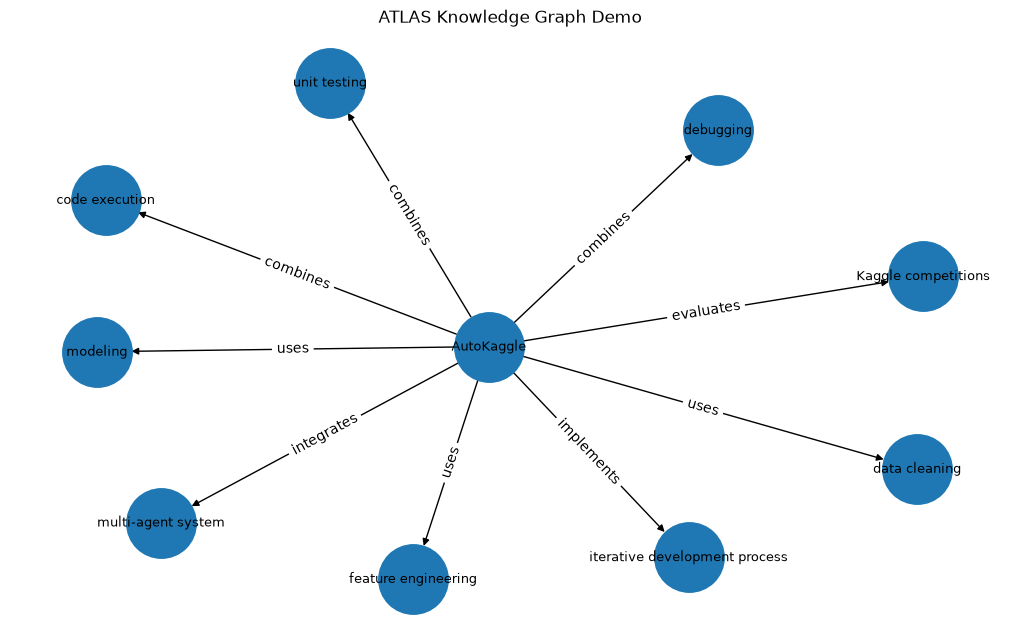

In [13]:
# Visualization

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(
    graph,
    seed=42
)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

edge_labels = nx.get_edge_attributes(
    graph,
    "relation"
)

nx.draw_networkx_edge_labels(
    graph,
    pos,
    edge_labels=edge_labels
)

plt.title(
    "ATLAS Knowledge Graph Demo"
)

plt.show()

In [14]:
# Export Graph

import json
import networkx as nx

with open("graph.json", "w") as f:
    json.dump(
        nx.node_link_data(graph),
        f,
        indent=2
    )

In [15]:
nx.write_graphml(graph, "atlas_graph.graphml")

In [16]:
!ls

atlas_demo_v0.ipynb atlas_graph.graphml atlas_v1.ipynb      graph.json
